# Tutorial for XC-ID 
(X Chromosome inactivation - IDentifier)

2025-10-23

In [1]:
import os

import numpy as np
import pandas as pd
import xcid

import matplotlib.pyplot as plt

Set up sample information

In [2]:
base_dir = '../data'
os.chdir(base_dir)
chromosome = 'X' # indicate right chromosome

Provide paths for all input files

In [3]:
# provide bams in a list (can provide multiple files)
# make sure to index the bams (.bai files should be in the same directory as the bam files)
bams = ['WASP_X.bam']
# vcf files should be provided in a list
vcf_files = ['variants.vcf']

## Run the full pipeline

In [ ]:
xc = xcid.XCID(
    vcf_files=vcf_files,
    bam_files=bams,
    cells_file='barcodes.txt', # optionally provide a file with cell barcodes
    chromosome=chromosome,
    rand_seed=206,
)

In [ ]:
results = xc.run_all()
results.head(10)

1. Loading data and constructing count matrices...
267 SNPs loaded from X
Number of filtered cells provided: 2000
Loaded 267 SNP positions with coverage.
Loaded 1968 cells with informative reads.
Filtered out 0 cells not in the filtered list.
Filtering SNPs based on minimum coverage=5, MAF=0.1
Final SNPs to phase: 265
Remaining informative cells: 1890 out of 1968.
2. Assigning haplotypes via simulated annealing...
Running simulated annealing with 1 initializations, 15000 max iterations.
Initial temperature: 265000, cooling rate: 0.995.
Iteration 0: cost=[-4400.]
Current temperature: 265000.0
Iteration 3750: cost=[-16142.]
Current temperature: 0.0
Iteration 7500: cost=[-16212.]
Current temperature: 0.0
Iteration 11250: cost=[-16212.]
Current temperature: 0.0
Best cost found after 14999 iterations: -16212.0. Initial cost: -4340.0.
3. Estimating confidence via bootstrapping...
Performing 100 bootstraps to determine cell confidence...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:    5.0s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    5.5s finished


4. Compiling results table...
Done!


,cell_id,score,p_value,p_adj,XCI_status
0,ATGTTTGAGGTTACGT,-4.087463,1.270427e-16,3.654652e-16,X1
1,AGGTTTGGTGGTGAGA,-0.584963,4.602054e-01,4.941978e-01,unknown
2,ACTCCTCAGACCATAC,-4.392317,1.531645e-17,5.132640e-17,X1
3,ACCCTGTTCTACCTGC,-2.807355,4.142226e-14,8.528112e-14,X1
4,ACAACAGAGGCTGTGC,3.169925,6.564908e-15,1.491307e-14,X0
...,...,...,...,...,...
1885,ACCTGTTGTACCGGAT,-2.000000,2.844397e-02,3.215257e-02,X1
1886,AACTACTCATTATCCC,-1.584963,9.939835e-01,1.000000e+00,unknown
1887,ACTTGTAAGCAGGCCT,-2.321928,3.073903e-11,4.936004e-11,X1
1888,ACCTTGCTCTCCTCAA,-2.321928,6.178233e-01,6.537996e-01,unknown


In [ ]:
print(results['XCI_status'].value_counts())
conf = results.loc[results['XCI_status'] != 'unknown', :]
print(conf.shape[0], 'confident cells detected out of ', results.shape[0], 'total cells.')

XCI_status
X1         1142
X0          537
unknown     211
Name: count, dtype: int64
1679 confident cells


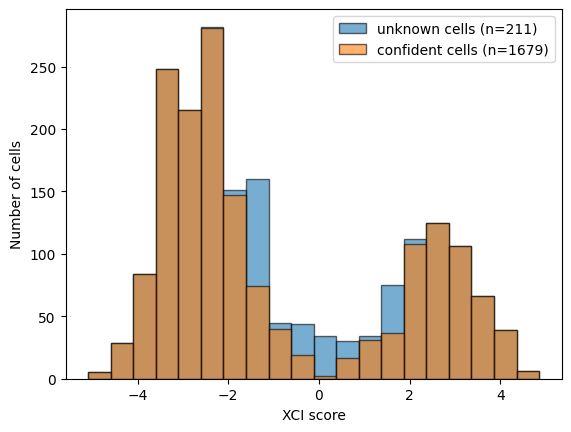

In [10]:
results['score'].hist(bins=20, label='unknown cells (n=211)', 
                      alpha=0.6, edgecolor='black', linewidth=1)
conf['score'].hist(bins=20, label='confident cells (n=1679)', 
                   alpha=0.6, edgecolor='black', linewidth=1)
plt.xlabel('XCI score')
plt.ylabel('Number of cells')
plt.grid(None)
plt.legend()
plt.show()

In [ ]:
os.mkdir('results', exist_ok=True)
results.to_csv('results/results.tsv', sep='\t', index=False)

In [ ]:
escape_table = xc.escape_table(min_cells=1)
escape_table.head(10)

In [ ]:
escape_table.to_csv('results/escape_table.tsv', sep='\t', index=False)